### Task 8: Unet

In [1]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
i_size = 256
bach_size = 8
lr = 0.0001
epochs = 5
IMAGE_DIR = "/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images"
MASK_DIR = "/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Masks"

In [3]:
# DA (3.1)
train_transform = A.Compose([
    A.Resize(i_size, i_size),
    A.HorizontalFlip(p=0.5), #p is probability in this case
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.0,0.0,0.0), std=(1.0,1.0,1.0)), #zscore norm.
    ToTensorV2() #noscaling
])

In [4]:
class FloodDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx] #debugged after 1
        image_path = os.path.join(self.image_dir,self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])
        image = cv.imread(image_path)
        mask = cv.imread(mask_path, 0)
        if image is None or mask is None:
            print(f"Skipping bad file: {img_name}")
            return self.__getitem__((idx + 1) % len(self.images)) #debugged after 1
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        mask = (mask > 0).astype(np.float32) #masking on T/F
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        return image, mask.unsqueeze(0)

In [5]:
#loadit
dataset = FloodDataset(IMAGE_DIR, MASK_DIR, transform=train_transform)
loader = DataLoader(dataset, batch_size=bach_size, shuffle=True)

In [6]:
#MAIN
class doubleconv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__() #prevents overriding parent init
        self.conv = nn.Sequential( #makes sure that chronology of i/o followed
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
class UNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = doubleconv(3, 64)
        self.p1 = nn.MaxPool2d(2) #stride=2
        self.d2 = doubleconv(64, 128)
        self.p2 = nn.MaxPool2d(2)
        self.d3 = doubleconv(128, 256)
        self.p3 = nn.MaxPool2d(2)
        self.d4 = doubleconv(256, 512)
        self.p4 = nn.MaxPool2d(2)
        self.neck = doubleconv(512, 1024) #downpart ends
        #class torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride=1)
        self.u1 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.c1 = doubleconv(1024, 512)
        self.u2 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c2 = doubleconv(512, 256)
        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = doubleconv(256, 128)
        self.u4 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c4 = doubleconv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))
        d4 = self.d4(self.p3(d3))
        bn = self.neck(self.p4(d4)) #downpart done
        u1 = self.u1(bn)
        u1 = torch.cat([u1, d4], dim=1) #skipconnection made
        u1 = self.c1(u1)
        u2 = self.u2(u1)
        u2 = torch.cat([u2, d3], dim=1)
        u2 = self.c2(u2)
        u3 = self.u3(u2)
        u3 = torch.cat([u3, d2], dim=1)
        u3 = self.c3(u3)
        u4 = self.u4(u3)
        u4 = torch.cat([u4, d1], dim=1)
        u4 = self.c4(u4)
        return torch.sigmoid(self.out(u4))
                     
        
        

In [7]:
#lossfn
bce = nn.BCELoss()
def dice_loss(pred, target):
    smooth = 1e-6
    pred = pred.view(-1)
    target = target.view(-1)
    intersec = (pred*target).sum()
    return 1 - ((2*intersec+smooth)/(pred.sum() + target.sum() + smooth))

In [8]:
#set
model = UNET().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [9]:
#trainingloops
for epoch in range(epochs):
    model.train()
    loop = tqdm(loader)
    tloss = 0
    for imgs,mask in loop:
        imgs = imgs.to(device)
        masks = mask.to(device)
        preds = model(imgs)
        loss = bce(preds, masks)+dice_loss(preds, masks)
        optimizer.zero_grad() #clears oldgrd.
        loss.backward()
        optimizer.step() #updateweight
        tloss += loss.item()
        loop.set_postfix(loss=loss.item()) #text at endof bar
    print(f"Epoch {epoch+1}/{epochs}, Loss: {tloss/len(loader)}")

 33%|███▎      | 140/426 [01:55<04:21,  1.09it/s, loss=0.693]libpng error: Read Error


Skipping bad file: aug_147_1679.png


100%|██████████| 426/426 [06:06<00:00,  1.16it/s, loss=1.06]


Epoch 1/5, Loss: 0.8304749625109731


 94%|█████████▍| 401/426 [04:23<00:16,  1.51it/s, loss=0.546]libpng error: Read Error


...

Epoch 4/5, Loss: 0.589223497770202


 35%|███▍      | 147/426 [01:36<03:03,  1.52it/s, loss=0.527]libpng error: Read Error


Skipping bad file: aug_147_1679.png


100%|██████████| 426/426 [04:39<00:00,  1.53it/s, loss=0.48]

Epoch 5/5, Loss: 0.5545528285520177


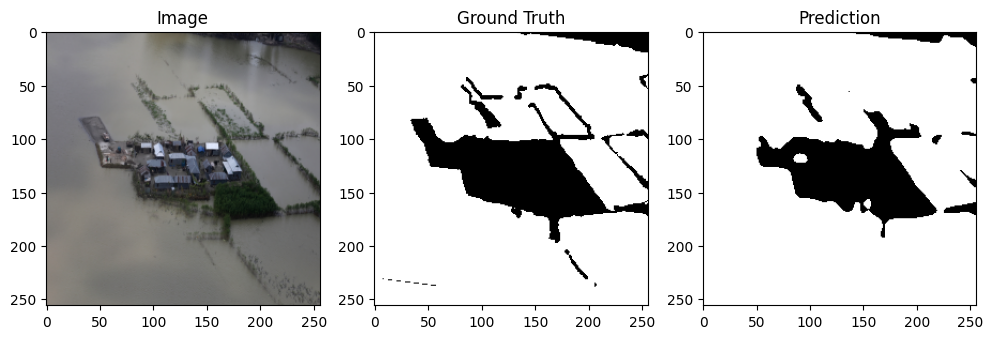

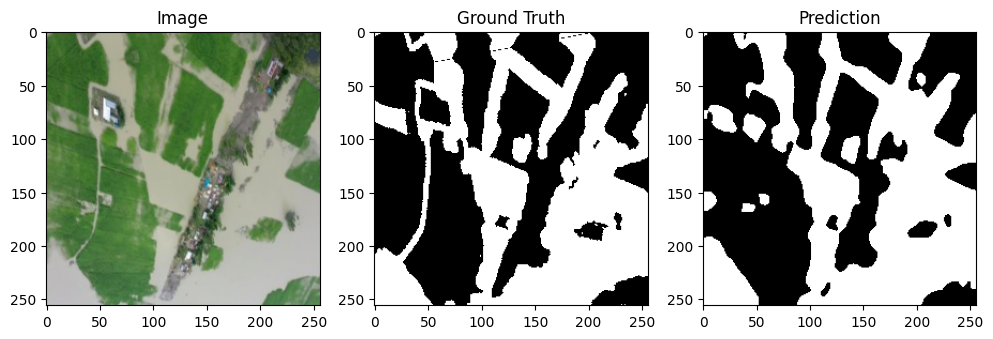

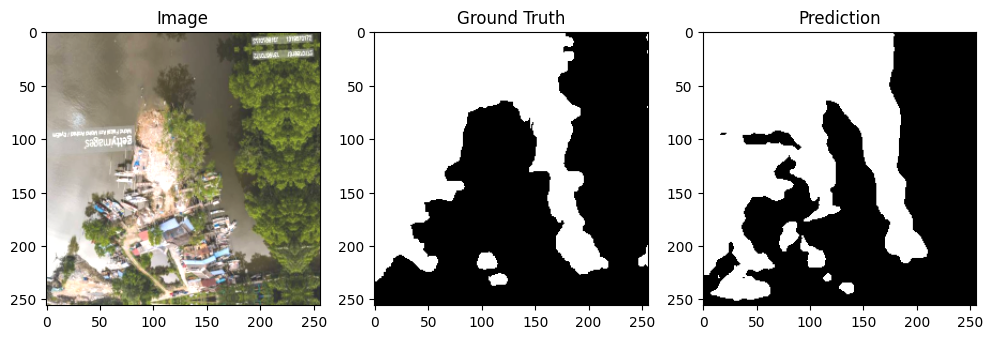

In [10]:
def show_predictions(model, dataset, num=3):
    model.eval()
    for i in range(num):
        img, mask = dataset[i]
        with torch.no_grad(): #grad. disable
            pred = model(img.unsqueeze(0).to(device))[0]
        img = img.permute(1,2,0).cpu().numpy()
        pred = pred.squeeze().cpu().numpy()
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img)
        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask.squeeze(), cmap='gray')
        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred > 0.5, cmap='gray')
        plt.show()
show_predictions(model, dataset)